<a href="https://colab.research.google.com/github/AbiniveshMayilsamy/DSIndustryChallenge-q59/blob/main/DS59.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# 2. Macro Digital Payments Analysis (data.csv)

In [4]:
data_csv_path = 'data.csv' if os.path.exists('data.csv') else ('/content/data.csv' if os.path.exists('/content/data.csv') else 'data.csv')

macro_df = pd.read_csv(data_csv_path)
display(macro_df.head(10))
macro_df.info()

macro_df['Month_Year_Clean'] = macro_df['Month/Year'].str.replace("'", "")
macro_df['Date'] = pd.to_datetime(macro_df['Month_Year_Clean'], format='%b%y', errors='coerce')
macro_df = macro_df.sort_values('Date').reset_index(drop=True)
display(macro_df.describe())

,Month/Year,Volume (Cr),Value (in Lakh Crores)
0,Oct'16,79.67,108.70
1,Nov'16,91.83,112.27
2,Dec'16,132.93,124.57
3,Jan'17,125.61,113.94
4,Feb'17,111.37,107.98
5,Mar'17,130.64,172.61
6,April'17,159.74,148.43
7,May'17,156.89,151.45
8,June'17,153.02,154.43
9,July'17,156.71,145.76


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month/Year              20 non-null     object 
 1   Volume (Cr)             20 non-null     float64
 2   Value (in Lakh Crores)  20 non-null     float64
dtypes: float64(2), object(1)
memory usage: 612.0+ bytes


,Volume (Cr),Value (in Lakh Crores),Date
count,20.000000,20.000000,17
mean,158.286000,152.300000,2017-07-26 21:10:35.294117632
min,79.670000,107.980000,2016-10-01 00:00:00
25%,132.357500,140.462500,2017-02-01 00:00:00
50%,158.495000,153.295000,2017-09-01 00:00:00
75%,191.930000,169.260000,2018-01-01 00:00:00
max,214.310000,216.860000,2018-05-01 00:00:00
std,37.744038,27.988863,NaN


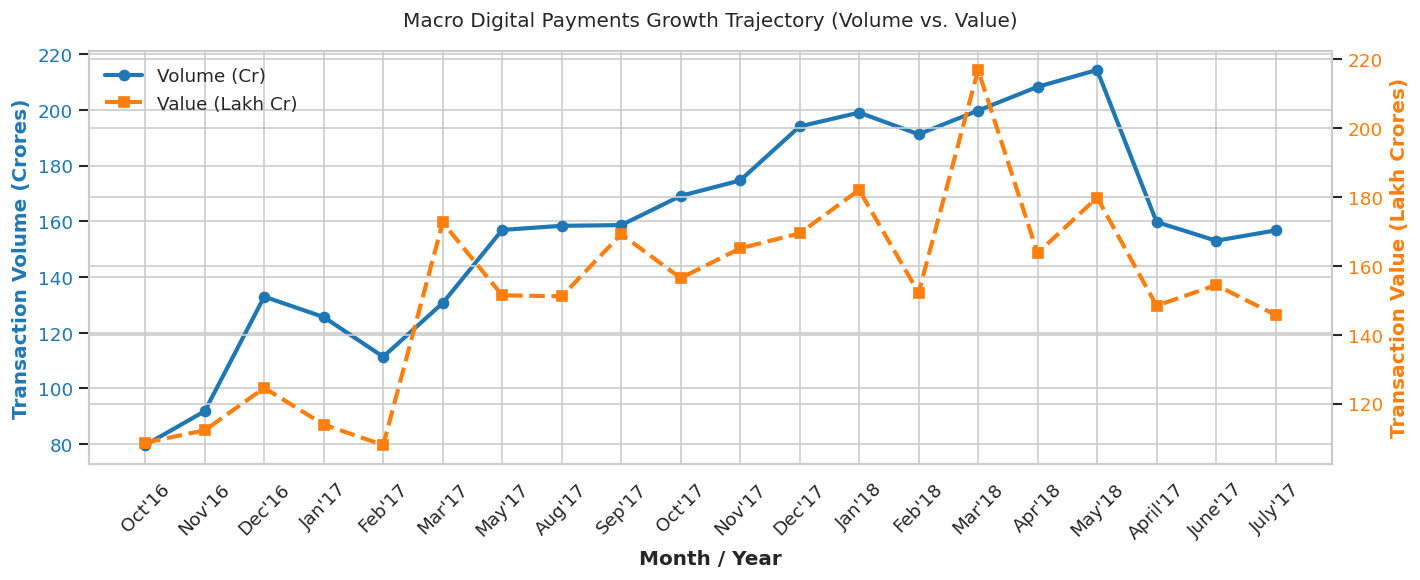

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Month / Year', fontweight='bold')
ax1.set_ylabel('Transaction Volume (Crores)', color=color, fontweight='bold')
line1 = ax1.plot(macro_df['Month/Year'], macro_df['Volume (Cr)'], color=color, marker='o', linewidth=2.5, label='Volume (Cr)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Transaction Value (Lakh Crores)', color=color, fontweight='bold')
line2 = ax2.plot(macro_df['Month/Year'], macro_df['Value (in Lakh Crores)'], color=color, marker='s', linewidth=2.5, linestyle='--', label='Value (Lakh Cr)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Macro Digital Payments Growth Trajectory (Volume vs. Value)', pad=15)
plt.tight_layout()
plt.show()

# 3. Clean and Validate Transaction Dataset

In [6]:
tx_log_path = 'PS_20174392719_1491204439457_log.csv' if os.path.exists('PS_20174392719_1491204439457_log.csv') else ('/content/PS_20174392719_1491204439457_log.csv' if os.path.exists('/content/PS_20174392719_1491204439457_log.csv') else 'PS_20174392719_1491204439457_log.csv')

df = pd.read_csv(tx_log_path)
display(df.head())
display(df.isnull().sum())

numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['orig_account_type'] = df['nameOrig'].astype(str).str[0]
df['dest_account_type'] = df['nameDest'].astype(str).str[0]
df['channel_route'] = df['orig_account_type'] + '2' + df['dest_account_type']

df.info()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


<class 'pandas.core.frame.DataFrame'>
Index: 56202 entries, 0 to 56201
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   step               56202 non-null  int64  
 1   type               56202 non-null  object 
 2   amount             56202 non-null  float64
 3   nameOrig           56202 non-null  object 
 4   oldbalanceOrg      56202 non-null  float64
 5   newbalanceOrig     56202 non-null  float64
 6   nameDest           56202 non-null  object 
 7   oldbalanceDest     56202 non-null  float64
 8   newbalanceDest     56202 non-null  float64
 9   isFraud            56202 non-null  float64
 10  isFlaggedFraud     56202 non-null  float64
 11  orig_account_type  56202 non-null  object 
 12  dest_account_type  56202 non-null  object 
 13  channel_route      56202 non-null  object 
dtypes: float64(7), int64(1), object(6)
memory usage: 6.4+ MB


# 4. Overall Failure Rate and Success Rates by Payment Method

In [7]:
total_tx = len(df)
failed_tx = df['isFraud'].sum()
successful_tx = total_tx - failed_tx
overall_failure_rate = df['isFraud'].mean()

print(f"Total Transactions: {total_tx:,}")
print(f"Successful Transactions: {successful_tx:,} ({((1 - overall_failure_rate) * 100):.4f}%)")
print(f"Failed Transactions: {failed_tx:,} ({overall_failure_rate * 100:.4f}%)")

type_breakdown = df.groupby('type').agg(
    Total_Count=('isFraud', 'count'),
    Failed_Count=('isFraud', 'sum'),
    Failure_Rate=('isFraud', 'mean')
).reset_index()

type_breakdown['Success_Count'] = type_breakdown['Total_Count'] - type_breakdown['Failed_Count']
type_breakdown['Success_Rate_Pct'] = (1 - type_breakdown['Failure_Rate']) * 100
type_breakdown['Failure_Rate_Pct'] = type_breakdown['Failure_Rate'] * 100
type_breakdown['Failure_Share_Pct'] = (type_breakdown['Failed_Count'] / failed_tx) * 100

display(type_breakdown.sort_values('Failure_Rate', ascending=False))

Total Transactions: 56,202
Successful Transactions: 56,102.0 (99.8221%)
Failed Transactions: 100.0 (0.1779%)


,type,Total_Count,Failed_Count,Failure_Rate,Success_Count,Success_Rate_Pct,Failure_Rate_Pct,Failure_Share_Pct
4,TRANSFER,5267,49.0,0.009303,5218.0,99.069679,0.930321,49.0
1,CASH_OUT,15672,51.0,0.003254,15621.0,99.674579,0.325421,51.0
0,CASH_IN,10321,0.0,0.000000,10321.0,100.000000,0.000000,0.0
2,DEBIT,700,0.0,0.000000,700.0,100.000000,0.000000,0.0
3,PAYMENT,24242,0.0,0.000000,24242.0,100.000000,0.000000,0.0


# 5. Failure Rates by Time of Day and Spike Identification

In [8]:
df['hour_of_day'] = (df['step'] % 24).astype(int)

def categorize_time_of_day(hour):
    if 0 <= hour < 6:
        return 'Late Night (00:00-05:59)'
    elif 6 <= hour < 12:
        return 'Morning (06:00-11:59)'
    elif 12 <= hour < 18:
        return 'Afternoon (12:00-17:59)'
    else:
        return 'Evening (18:00-23:59)'

df['time_slot'] = df['hour_of_day'].apply(categorize_time_of_day)

hourly_analysis = df.groupby('hour_of_day').agg(
    Total_Volume=('isFraud', 'count'),
    Failures=('isFraud', 'sum'),
    Failure_Rate=('isFraud', 'mean')
).reset_index()
hourly_analysis['Failure_Rate_Pct'] = hourly_analysis['Failure_Rate'] * 100

mean_rate = hourly_analysis['Failure_Rate_Pct'].mean()
std_rate = hourly_analysis['Failure_Rate_Pct'].std()
hourly_analysis['Z_Score'] = (hourly_analysis['Failure_Rate_Pct'] - mean_rate) / std_rate
hourly_analysis['Is_Spike'] = hourly_analysis['Z_Score'] > 1.5

display(hourly_analysis)

timeslot_analysis = df.groupby('time_slot').agg(
    Total_Volume=('isFraud', 'count'),
    Failures=('isFraud', 'sum'),
    Failure_Rate_Pct=('isFraud', lambda x: x.mean() * 100)
).reset_index().sort_values('Failure_Rate_Pct', ascending=False)

display(timeslot_analysis)

,hour_of_day,Total_Volume,Failures,Failure_Rate,Failure_Rate_Pct,Z_Score,Is_Spike
0,1,2708,16.0,0.005908,0.590842,-0.203109,False
1,2,1014,8.0,0.007890,0.788955,0.137221,False
2,3,552,4.0,0.007246,0.724638,0.026733,False
3,4,565,10.0,0.017699,1.769912,1.822366,True
4,5,665,6.0,0.009023,0.902256,0.331856,False
5,6,1660,22.0,0.013253,1.325301,1.058589,False
6,7,6837,12.0,0.001755,0.175516,-0.916582,False
7,8,21097,12.0,0.000569,0.056880,-1.120381,False
8,9,21104,10.0,0.000474,0.047384,-1.136693,False


,time_slot,Total_Volume,Failures,Failure_Rate_Pct
0,Late Night (00:00-05:59),5504,44.0,0.799419
1,Morning (06:00-11:59),50698,56.0,0.110458


# 6. Transaction Amount Association with Failures

In [9]:
display(df.groupby('isFraud')['amount'].describe())

df['amount_tier'] = pd.qcut(df['amount'], q=5, labels=['Tier 1 (Very Low)', 'Tier 2 (Low)', 'Tier 3 (Medium)', 'Tier 4 (High)', 'Tier 5 (Very High)'])
amount_tier_analysis = df.groupby('amount_tier', observed=False).agg(
    Total_Tx=('isFraud', 'count'),
    Failed_Tx=('isFraud', 'sum'),
    Failure_Rate_Pct=('isFraud', lambda x: x.mean() * 100),
    Mean_Amount=('amount', 'mean')
).reset_index()

display(amount_tier_analysis)

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0.0,56102.0,159154.396012,3.218751e+05,0.63,8127.0375,36254.995,191765.70,5677662.29
1.0,100.0,573937.718400,1.644365e+06,164.00,14949.8400,31926.940,262434.54,10000000.00


,amount_tier,Total_Tx,Failed_Tx,Failure_Rate_Pct,Mean_Amount
0,Tier 1 (Very Low),11241,10.0,0.088960,2991.716628
1,Tier 2 (Low),11240,16.0,0.142349,10797.940681
2,Tier 3 (Medium),11240,36.0,0.320285,42875.596457
3,Tier 4 (High),11240,12.0,0.106762,157488.471166
4,Tier 5 (Very High),11241,26.0,0.231296,585284.479755


# 7. Random Forest Model Training and Evaluation

In [10]:
df['balance_change_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['orig_balance_error'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']
df['dest_balance_error'] = (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']

encoded_model_df = pd.get_dummies(df, columns=['type', 'channel_route'], drop_first=False)

features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
    'hour_of_day', 'balance_change_orig', 'balance_change_dest',
    'orig_balance_error', 'dest_balance_error'
] + [c for c in encoded_model_df.columns if c.startswith('type_') or c.startswith('channel_route_')]

X = encoded_model_df[features]
y = encoded_model_df['isFraud']

fraud_indices = y[y == 1].index
non_fraud_indices = y[y == 0].index

np.random.seed(42)
sampled_non_fraud_indices = np.random.choice(non_fraud_indices, size=len(fraud_indices) * 4, replace=False)
balanced_indices = np.concatenate([fraud_indices, sampled_non_fraud_indices])

X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.30, random_state=42, stratify=y_balanced
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=14,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9867
Precision: 0.9375
Recall   : 1.0000
F1-Score : 0.9677
ROC-AUC  : 0.9994

Classification Report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9833    0.9916       120
         1.0     0.9375    1.0000    0.9677        30

    accuracy                         0.9867       150
   macro avg     0.9688    0.9917    0.9797       150
weighted avg     0.9875    0.9867    0.9868       150

Confusion Matrix:
[[118   2]
 [  0  30]]


,Feature,Importance
0,orig_balance_error,0.190430
1,balance_change_orig,0.112942
2,newbalanceOrig,0.105379
3,hour_of_day,0.099428
4,step,0.098870
5,type_TRANSFER,0.050526
6,amount,0.048427
7,oldbalanceDest,0.047118
8,channel_route_C2M,0.045332
9,channel_route_C2C,0.041042


/tmp/ipykernel_2920/1294359249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='Blues_r')


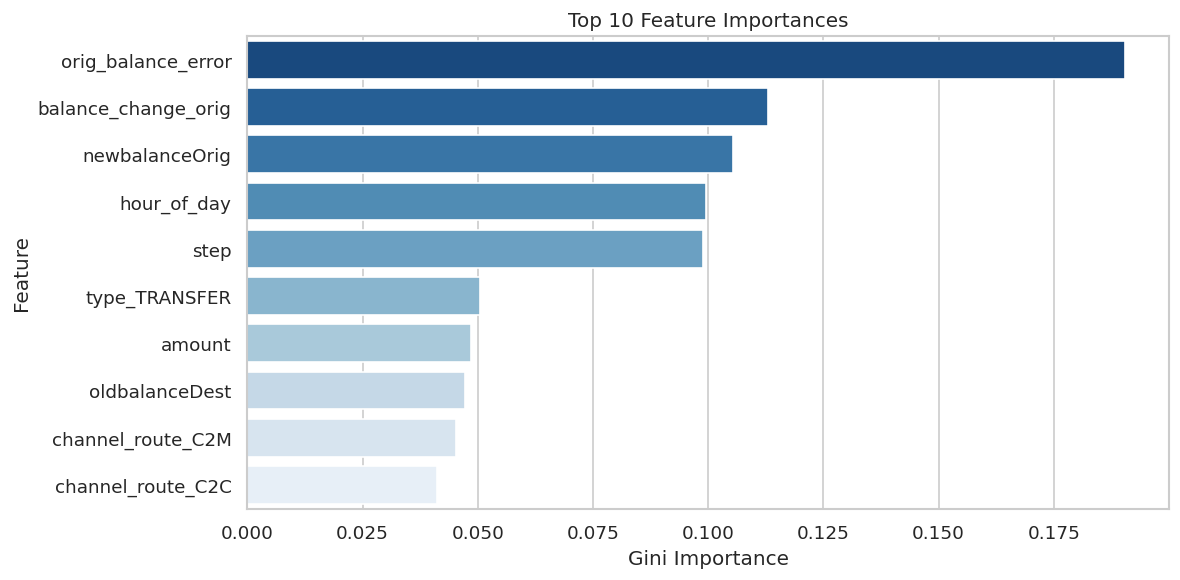

In [11]:
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importances.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 10 Feature Importances')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 8. Operational Dashboard

/tmp/ipykernel_2920/2317681702.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_breakdown, x='type', y='Failure_Rate_Pct', ax=ax2, palette='magma')
/tmp/ipykernel_2920/2317681702.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amount_tier_analysis, x='amount_tier', y='Failure_Rate_Pct', ax=ax4, palette='viridis')


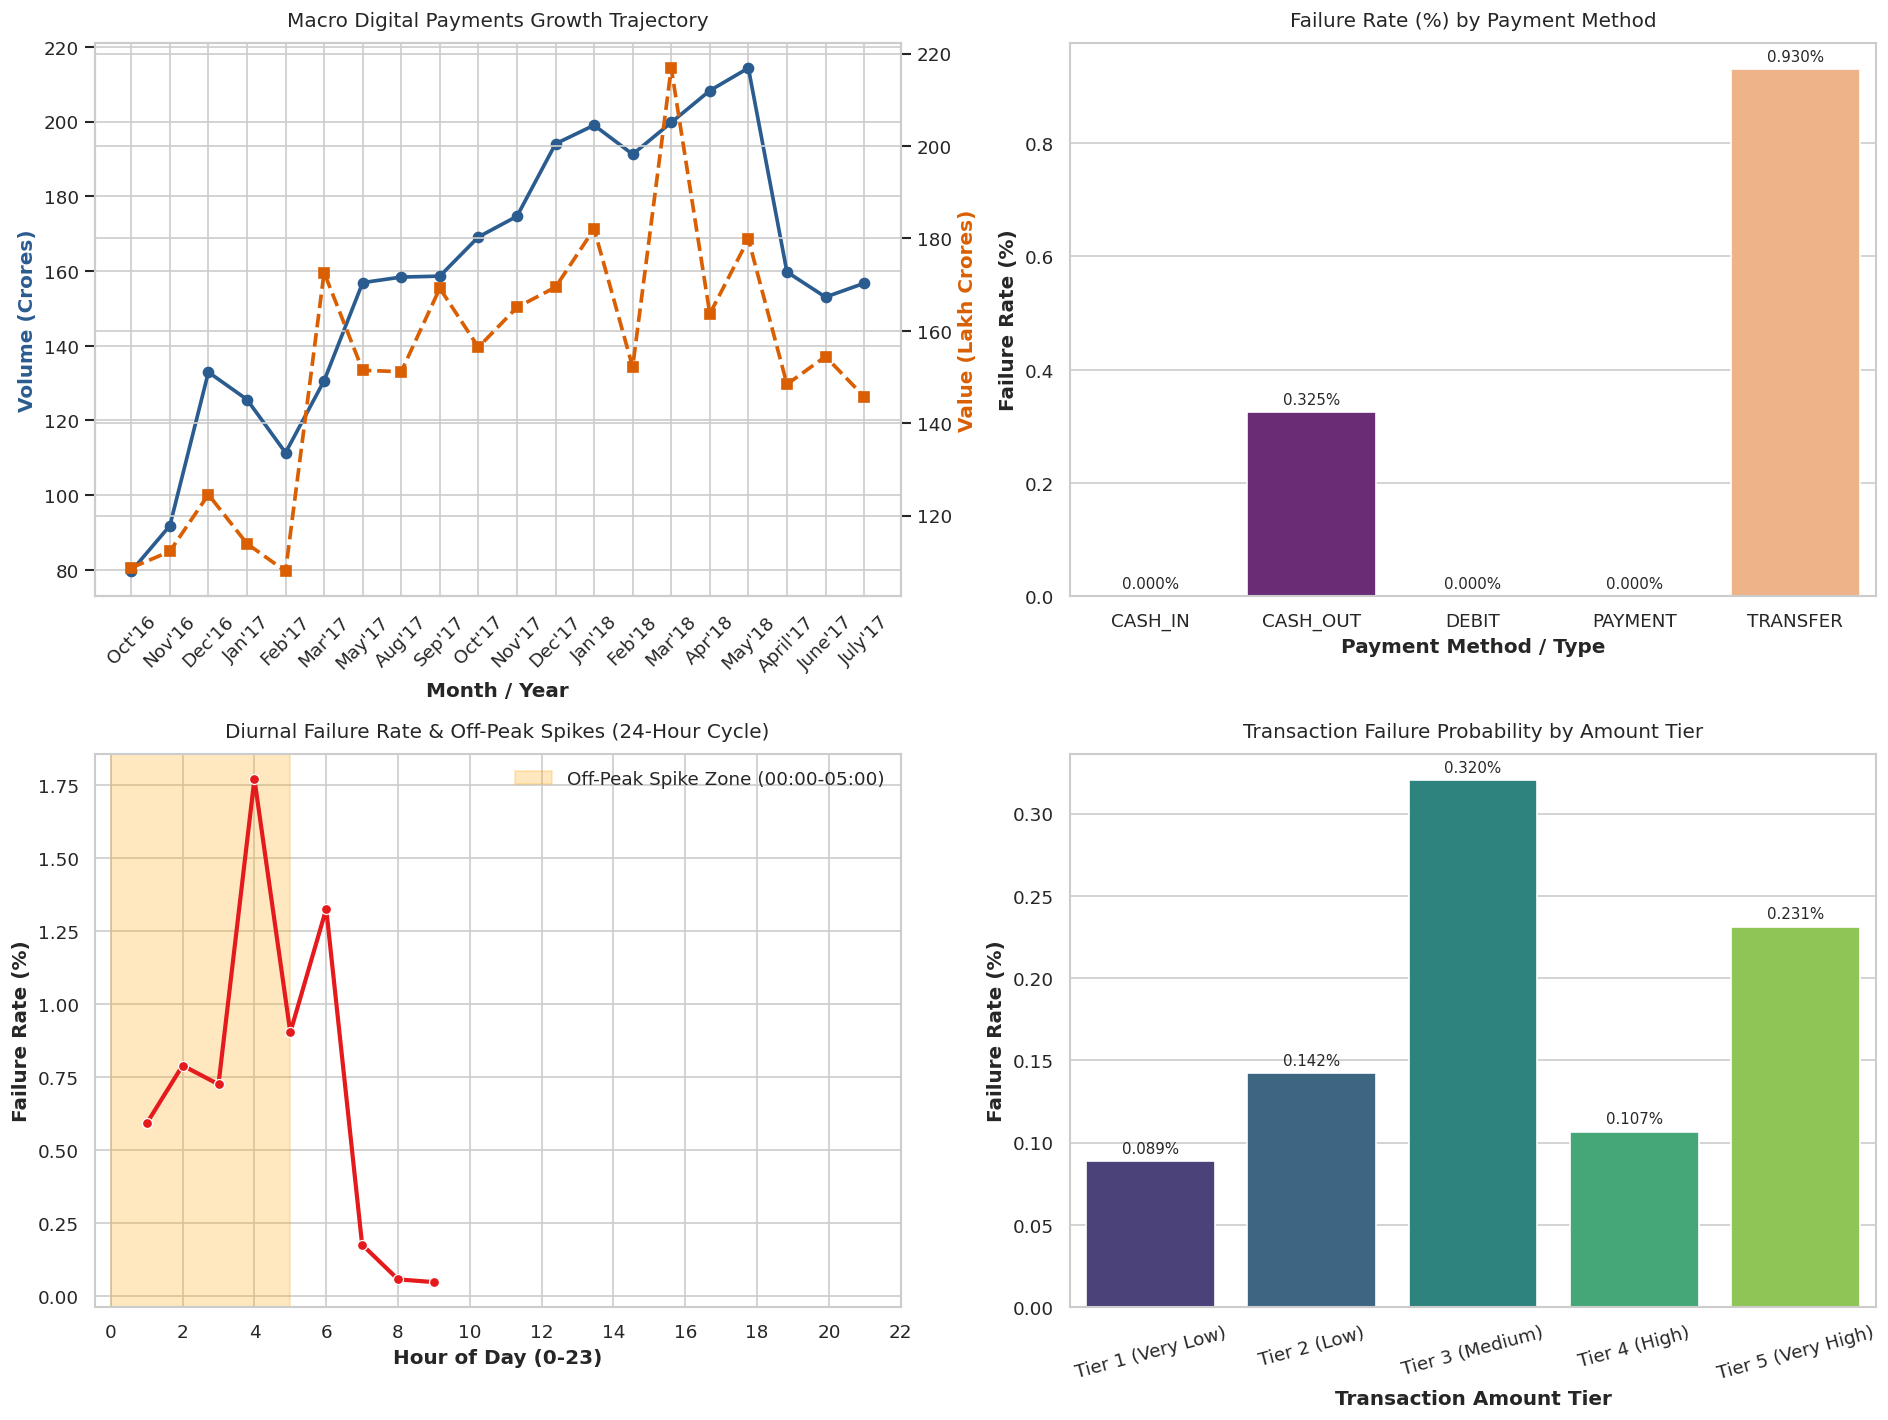

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Macro Payment Trends
ax1 = axes[0, 0]
color1 = '#2b5c8f'
color2 = '#d95f02'
ax1.plot(macro_df['Month/Year'], macro_df['Volume (Cr)'], marker='o', color=color1, linewidth=2.2, label='Volume (Cr)')
ax1.set_xlabel('Month / Year', fontweight='bold')
ax1.set_ylabel('Volume (Crores)', color=color1, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1_twin = ax1.twinx()
ax1_twin.plot(macro_df['Month/Year'], macro_df['Value (in Lakh Crores)'], marker='s', color=color2, linewidth=2.2, linestyle='--', label='Value (Lakh Cr)')
ax1_twin.set_ylabel('Value (Lakh Crores)', color=color2, fontweight='bold')
ax1.set_title('Macro Digital Payments Growth Trajectory', pad=10)

# Panel 2: Failure Rate Across Payment Methods
ax2 = axes[0, 1]
sns.barplot(data=type_breakdown, x='type', y='Failure_Rate_Pct', ax=ax2, palette='magma')
ax2.set_title('Failure Rate (%) by Payment Method', pad=10)
ax2.set_xlabel('Payment Method / Type', fontweight='bold')
ax2.set_ylabel('Failure Rate (%)', fontweight='bold')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Panel 3: 24-Hour Diurnal Failure Rate & Anomaly Spikes
ax3 = axes[1, 0]
sns.lineplot(data=hourly_analysis, x='hour_of_day', y='Failure_Rate_Pct', ax=ax3, marker='o', color='#e41a1c', linewidth=2.5)
ax3.axvspan(0, 5, color='orange', alpha=0.25, label='Off-Peak Spike Zone (00:00-05:00)')
ax3.set_title('Diurnal Failure Rate & Off-Peak Spikes (24-Hour Cycle)', pad=10)
ax3.set_xlabel('Hour of Day (0-23)', fontweight='bold')
ax3.set_ylabel('Failure Rate (%)', fontweight='bold')
ax3.set_xticks(range(0, 24, 2))
ax3.legend(loc='upper right')

# Panel 4: Failure Rate by Amount Tier
ax4 = axes[1, 1]
sns.barplot(data=amount_tier_analysis, x='amount_tier', y='Failure_Rate_Pct', ax=ax4, palette='viridis')
ax4.set_title('Transaction Failure Probability by Amount Tier', pad=10)
ax4.set_xlabel('Transaction Amount Tier', fontweight='bold')
ax4.set_ylabel('Failure Rate (%)', fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
for p in ax4.patches:
    ax4.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()